# Solutions to Process 5
Investigate the validity of the proposed $\{PPB, \tau_\alpha\}$ system solved for $\{T_e, n_e\}$. Check plasma current fractions in more detail.

In [1]:
# Reload Process each time (keep editable install up-to-date)
%load_ext autoreload
%autoreload 2
from IPython.display import clear_output
import process
from process.main import SingleRun
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Running scipy's SLSQP


## Set up
Same as in `solutions_to_process_2.ipynb`.

## Plasma current
Currently, the plasma current is fixed, which needs to change. Run as before, but include plasma current.

In [2]:
w_fracs = np.linspace(5.0e-6, 1.0e-4, 20)
sol_data = {
    "w": [],
    "te": [],
    "ne": [],
    "ip": [],
    "f_c_plasma_bootstrap": [],
    "f_c_plasma_diamagnetic": [],
    "f_c_plasma_pfirsch_schluter": [],
    "f_c_plasma_inductive": [],
    "f_c_plasma_auxiliary": [],
    "f_c_plasma_current_sum": [],
}
for w_frac in w_fracs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["w"].append(w_frac)
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["ip"].append(process.fortran.physics_variables.plasma_current.item())
    sol_data["f_c_plasma_bootstrap"].append(
        process.fortran.current_drive_variables.f_c_plasma_bootstrap.item()
    )
    sol_data["f_c_plasma_diamagnetic"].append(
        process.fortran.current_drive_variables.f_c_plasma_diamagnetic.item()
    )
    sol_data["f_c_plasma_pfirsch_schluter"].append(
        process.fortran.current_drive_variables.f_c_plasma_pfirsch_schluter.item()
    )
    sol_data["f_c_plasma_inductive"].append(
        process.fortran.physics_variables.f_c_plasma_inductive.item()
    )
    sol_data["f_c_plasma_auxiliary"].append(
        process.fortran.physics_variables.f_c_plasma_auxiliary.item()
    )
    sol_data["f_c_plasma_current_sum"].append(
        process.fortran.physics_variables.f_c_plasma_current_sum.item()
    )

# Clear the lengthy stdout from multiple process runs
clear_output()

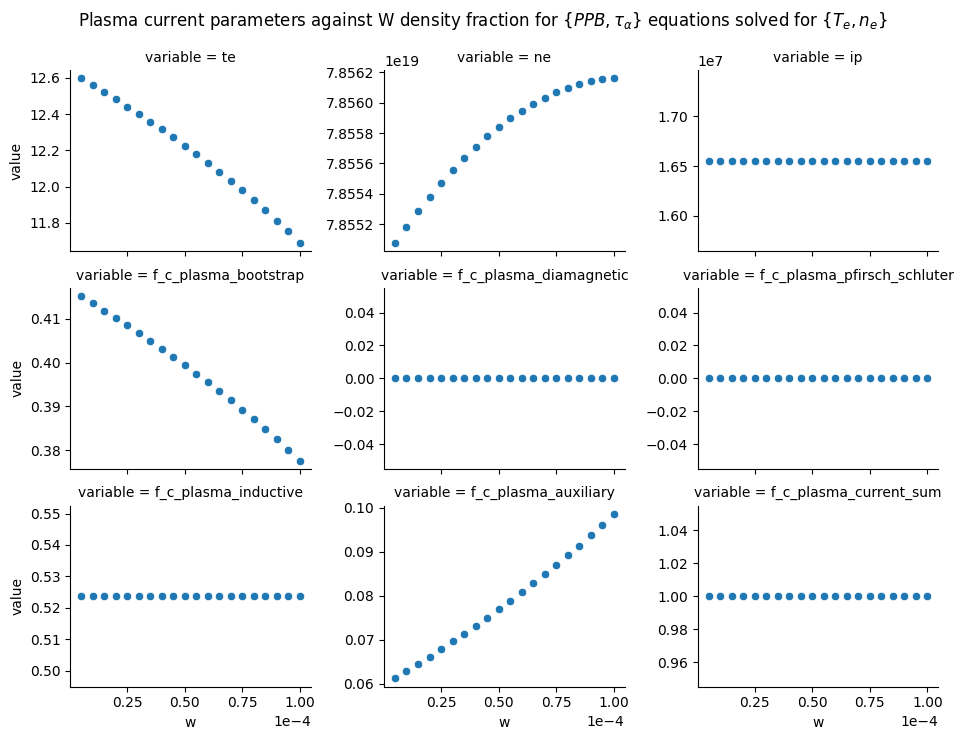

In [3]:
# Plot
sol_df = pd.DataFrame(sol_data)
sol_df_melt = sol_df.melt(id_vars="w")

fg = sns.relplot(
    data=sol_df_melt,
    x="w",
    y="value",
    col="variable",
    col_wrap=3,
    facet_kws=dict(sharey=False),
    height=2.5,
    aspect=1.3,
)
for axes in fg.axes.flat:
    axes.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))


fg.figure.suptitle(
    r"Plasma current parameters against W density fraction for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)
fg.figure.subplots_adjust(top=0.9)

ne now increases with W: check this and confirm it's after calculation of n_alpha / n_e as output.

In [4]:
kappas = np.linspace(1.7, 1.9, 20)
sol_data = {
    "kappa": [],
    "te": [],
    "ne": [],
    "ip": [],
    "f_c_plasma_bootstrap": [],
    "f_c_plasma_diamagnetic": [],
    "f_c_plasma_pfirsch_schluter": [],
    "f_c_plasma_inductive": [],
    "f_c_plasma_auxiliary": [],
    "f_c_plasma_current_sum": [],
}
for kappa in kappas:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_IN.DAT")
    process.fortran.physics_variables.kappa = kappa
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["kappa"].append(kappa)
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["ip"].append(process.fortran.physics_variables.plasma_current.item())
    sol_data["f_c_plasma_bootstrap"].append(
        process.fortran.current_drive_variables.f_c_plasma_bootstrap.item()
    )
    sol_data["f_c_plasma_diamagnetic"].append(
        process.fortran.current_drive_variables.f_c_plasma_diamagnetic.item()
    )
    sol_data["f_c_plasma_pfirsch_schluter"].append(
        process.fortran.current_drive_variables.f_c_plasma_pfirsch_schluter.item()
    )
    sol_data["f_c_plasma_inductive"].append(
        process.fortran.physics_variables.f_c_plasma_inductive.item()
    )
    sol_data["f_c_plasma_auxiliary"].append(
        process.fortran.physics_variables.f_c_plasma_auxiliary.item()
    )
    sol_data["f_c_plasma_current_sum"].append(
        process.fortran.physics_variables.f_c_plasma_current_sum.item()
    )

# Clear the lengthy stdout from multiple process runs
clear_output()

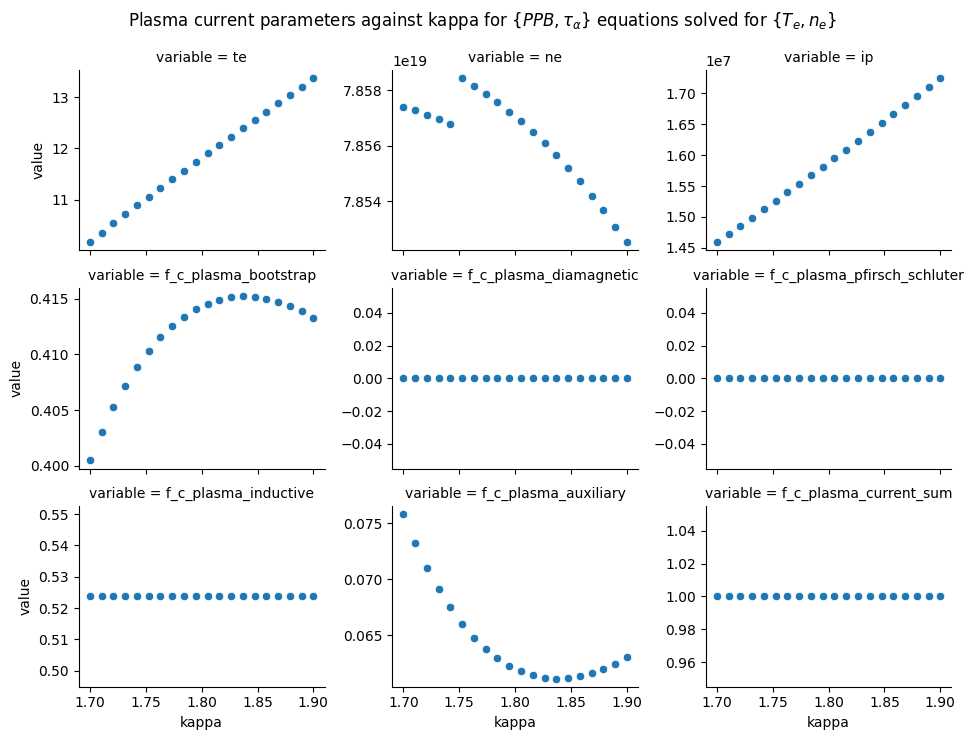

In [5]:
# Plot
sol_df = pd.DataFrame(sol_data)
sol_df_melt = sol_df.melt(id_vars="kappa")

fg = sns.relplot(
    data=sol_df_melt,
    x="kappa",
    y="value",
    col="variable",
    col_wrap=3,
    facet_kws=dict(sharey=False),
    height=2.5,
    aspect=1.3,
)
for axes in fg.axes.flat:
    axes.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))


fg.figure.suptitle(
    r"Plasma current parameters against kappa for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)
fg.figure.subplots_adjust(top=0.9)

In [6]:
triangs = np.linspace(0.4, 0.6, 20)
sol_data = {
    "triang": [],
    "te": [],
    "ne": [],
    "ip": [],
    "f_c_plasma_bootstrap": [],
    "f_c_plasma_diamagnetic": [],
    "f_c_plasma_pfirsch_schluter": [],
    "f_c_plasma_inductive": [],
    "f_c_plasma_auxiliary": [],
    "f_c_plasma_current_sum": [],
}
for triang in triangs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_IN.DAT")
    process.fortran.physics_variables.triang = triang
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["triang"].append(triang)
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["ip"].append(process.fortran.physics_variables.plasma_current.item())
    sol_data["f_c_plasma_bootstrap"].append(
        process.fortran.current_drive_variables.f_c_plasma_bootstrap.item()
    )
    sol_data["f_c_plasma_diamagnetic"].append(
        process.fortran.current_drive_variables.f_c_plasma_diamagnetic.item()
    )
    sol_data["f_c_plasma_pfirsch_schluter"].append(
        process.fortran.current_drive_variables.f_c_plasma_pfirsch_schluter.item()
    )
    sol_data["f_c_plasma_inductive"].append(
        process.fortran.physics_variables.f_c_plasma_inductive.item()
    )
    sol_data["f_c_plasma_auxiliary"].append(
        process.fortran.physics_variables.f_c_plasma_auxiliary.item()
    )
    sol_data["f_c_plasma_current_sum"].append(
        process.fortran.physics_variables.f_c_plasma_current_sum.item()
    )

# Clear the lengthy stdout from multiple process runs
clear_output()

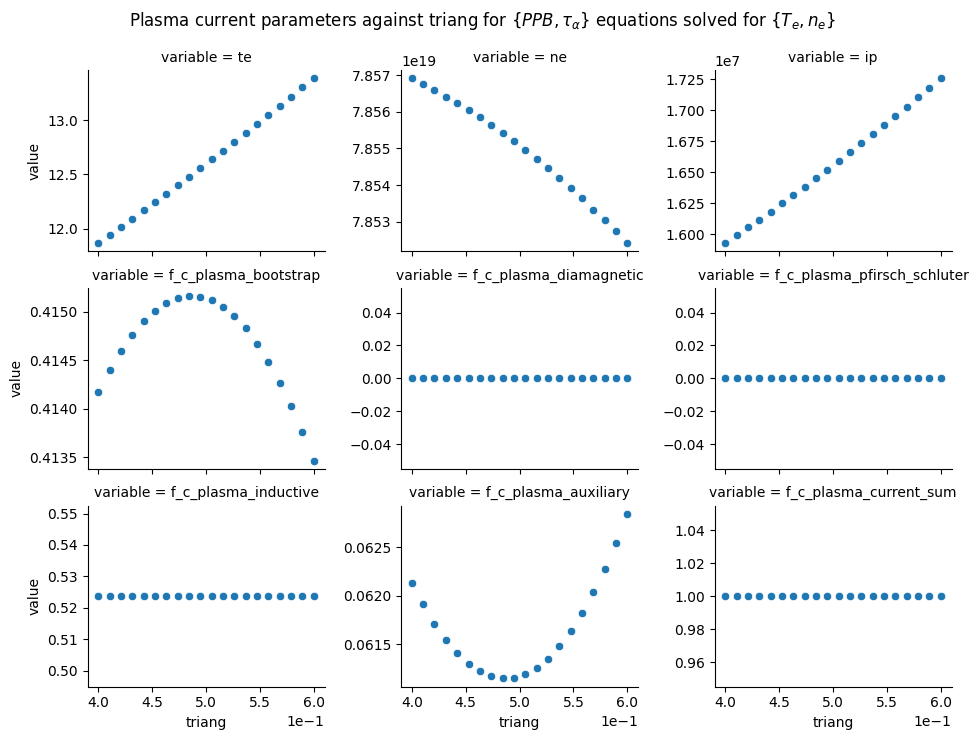

In [7]:
# Plot
sol_df = pd.DataFrame(sol_data)
sol_df_melt = sol_df.melt(id_vars="triang")

fg = sns.relplot(
    data=sol_df_melt,
    x="triang",
    y="value",
    col="variable",
    col_wrap=3,
    facet_kws=dict(sharey=False),
    height=2.5,
    aspect=1.3,
)
for axes in fg.axes.flat:
    axes.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))


fg.figure.suptitle(
    r"Plasma current parameters against triang for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)
fg.figure.subplots_adjust(top=0.9)

## Non-inductive case
See if plasma current fractions add up in non-inductive case.

Currently doesn't work due to div by 0 in TF coil stress calculation.

In [ ]:
w_fracs = np.linspace(5.0e-6, 1.0e-4, 20)
sol_data = {
    "w": [],
    "te": [],
    "ne": [],
    "ip": [],
    "f_c_plasma_bootstrap": [],
    "f_c_plasma_diamagnetic": [],
    "f_c_plasma_pfirsch_schluter": [],
    "f_c_plasma_inductive": [],
    "f_c_plasma_auxiliary": [],
    "f_c_plasma_current_sum": [],
}
for w_frac in w_fracs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["w"].append(w_frac)
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["ip"].append(process.fortran.physics_variables.plasma_current.item())
    sol_data["f_c_plasma_bootstrap"].append(
        process.fortran.current_drive_variables.f_c_plasma_bootstrap.item()
    )
    sol_data["f_c_plasma_diamagnetic"].append(
        process.fortran.current_drive_variables.f_c_plasma_diamagnetic.item()
    )
    sol_data["f_c_plasma_pfirsch_schluter"].append(
        process.fortran.current_drive_variables.f_c_plasma_pfirsch_schluter.item()
    )
    sol_data["f_c_plasma_inductive"].append(
        process.fortran.physics_variables.f_c_plasma_inductive.item()
    )
    sol_data["f_c_plasma_auxiliary"].append(
        process.fortran.physics_variables.f_c_plasma_auxiliary.item()
    )
    sol_data["f_c_plasma_current_sum"].append(
        process.fortran.physics_variables.f_c_plasma_current_sum.item()
    )

# Clear the lengthy stdout from multiple process runs
clear_output()

In [ ]:
# Plot
sol_df = pd.DataFrame(sol_data)
sol_df_melt = sol_df.melt(id_vars="w")

fg = sns.relplot(
    data=sol_df_melt,
    x="w",
    y="value",
    col="variable",
    col_wrap=3,
    facet_kws=dict(sharey=False),
    height=2.5,
    aspect=1.3,
)
for axes in fg.axes.flat:
    axes.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))


fg.figure.suptitle(
    r"Plasma current parameters against W density fraction for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)
fg.figure.subplots_adjust(top=0.9)